# ReasonVLM - Deep Schema Grounding (DSG)
This notebook explores grounding abstract concepts in mathematical graphs using the DSG framework.

In [1]:
import sys
import os

# This adds the directory containing the notebook to the Python path
module_path = os.path.abspath(os.getcwd())
if module_path not in sys.path:
    sys.path.append(module_path)

# Verify that the file is actually there
if os.path.exists('data_utils.py'):
    print("✅ data_utils.py found!")
else:
    print("❌ data_utils.py NOT found in:", os.getcwd())


✅ data_utils.py found!


In [2]:
# 1. Setup - Install necessary packages
!pip install datasets pillow matplotlib requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# 2. Import modular utilities
from data_utils import download_dynamath, filter_by_subject, display_item

print("Utilities imported successfully.")

c:\Users\vasu1\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Utilities imported successfully.


In [4]:
# 3. Download the DynaMath Sample dataset
dataset = download_dynamath(split='sample_variant1')

Download complete.


In [5]:
# 4. Filter for 'analytic geometry' (Graphs)
graph_dataset = filter_by_subject(dataset, 'analytic geometry')

Filtered dataset to 97 items with subject 'analytic geometry'.


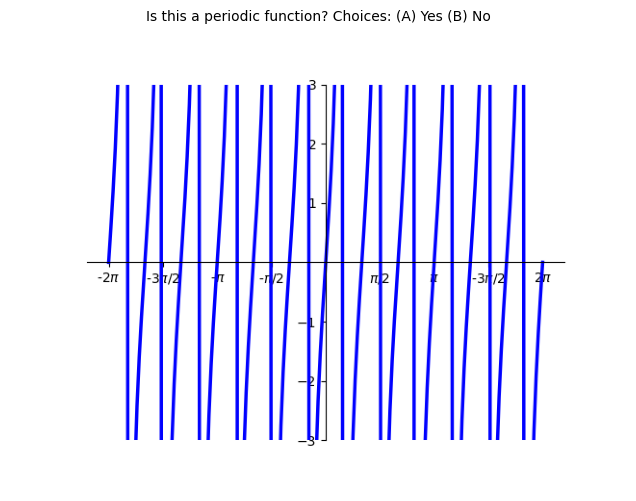

Subject: analytic geometry | Category: Unknown


In [7]:
# 5. Visualize a sample item
if len(graph_dataset) > 0:
    sample_item = graph_dataset[1]
    display_item(sample_item)
else:
    print("No items found in the filtered dataset.")

In [8]:
import os
import pandas as pd
from dsg_math_solver import solve_graph_problem
from data_utils import get_item_data
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

results = []
num_to_test = 5

print(f"--- STARTING BATCH EVALUATION ({num_to_test} items) ---\n")

for i in range(min(num_to_test, len(graph_dataset))):
    item = graph_dataset[i]
    question, img, answer_type, ground_truth = get_item_data(item)
    
    print(f"[{i+1}/{num_to_test}] Solving: {question[:50]}...")
    
    try:
        # Run the new precision-refined DSG
        dsg_result = solve_graph_problem(img, question, answer_type=answer_type, api_key=api_key, verbose=False)
        
        results.append({
            "Index": i,
            "Question": question,
            "Ground Truth": ground_truth,
            "DSG Answer": dsg_result["answer"],
            "Match": str(ground_truth).strip() == str(dsg_result["answer"]).strip()
        })
        print(f"   Done. Answer: {dsg_result['answer']}\n")
    except Exception as e:
        print(f"   Error on item {i}: {e}\n")

# Display Summary Table
df_results = pd.DataFrame(results)
display(df_results)


--- STARTING BATCH EVALUATION (5 items) ---

[1/5] Solving: What is the period of this function y = a*sin(b*x)...
   Done. Answer: 6.283

[2/5] Solving: Is this a periodic function? Choices: (A) Yes (B) ...
   Done. Answer: A

[3/5] Solving: What is the period of this function y = a*cos(b*x)...
   Done. Answer: 6.283

[4/5] Solving: The period of the red curve is ____ that of the bl...
   Done. Answer: ```json
{
    "solution": "The period of a sine wave is the distance between two consecutive peaks or troughs. Observing the graph, the red curve completes a full cycle between 0 and \(\pi\), while the blue curve completes a full cycle between 0 and \(2\pi\). Therefore, the period of the red curve is smaller than that of the blue curve.",
    "short answer": "C"
}
```

[5/5] Solving: how many zeros this function has? choice: (A) 2 (B...
   Done. Answer: B



,Index,Question,Ground Truth,DSG Answer,Match
0,0,What is the period of this function y = a*sin(...,2.0944,6.283,False
1,1,Is this a periodic function? Choices: (A) Yes ...,A,A,True
2,2,What is the period of this function y = a*cos(...,3.1416,6.283,False
3,3,The period of the red curve is ____ that of th...,C,"```json\n{\n ""solution"": ""The period of a s...",False
4,4,how many zeros this function has? choice: (A) ...,B,B,True


In [10]:
# Select the first failing item (Index 0)
item = graph_dataset[1]
question, img, answer_type, ground_truth = get_item_data(item)

print(f"DEBUGGING ITEM 0")
print(f"EXPECTED: {ground_truth}\n")

# Run with verbose=True to see every grounding step
dsg_result = solve_graph_problem(img, question, answer_type=answer_type, api_key=api_key, verbose=True)

print("\n--- FINAL DSG OUTPUT ---")
print(f"Solution: {dsg_result['solution']}")
print(f"Final Answer: {dsg_result['answer']}")


DEBUGGING ITEM 0
EXPECTED: A

Parsing Generic Graph Program...
Starting Grounding Loop for Concept: math-graph
Querying [axes limits and labels]: Imagine that the image represents math-graph, what is the axes limits and labels? Answer with one word or phrase only, do not elaborate.
Answer: -2π to 2π, -3 to 3
Querying [origin location and grid increments]: Imagine that the image represents math-graph and the axes limits and labels is -2π to 2π, -3 to 3, what is the origin location and grid increments? Answer with one word or phrase only, do not elaborate.
Answer: origin: (0, 0); increments: π/2, 1
Querying [curve type and qualitative shape]: Imagine that the image represents math-graph and the origin location and grid increments is origin: (0, 0); increments: π/2, 1, what is the curve type and qualitative shape? Answer with one word or phrase only, do not elaborate.
Answer: tangent
Querying [precise coordinates of intercepts and extrema]: Imagine that the image represents math-graph and